# Burn severity workflow
version 8

this notebook takes a file containing one or more burn extent polygons and perfoms the burn severity workflow on them. the out put is either single files per polygon or if desiered one merged geojson for all input polygons

note: combining the results of more that roughly 50 fires into one geojson results in a very large file that is more or less unuseable with a desktop computer and this is not adviseable. 

In [ ]:
import datacube
import geopandas as gpd
from datacube.utils.cog import write_cog
import os
from datetime import date, timedelta

from dea_burn_severity.burn_severity_config import RuntimeBurnConfig


config = RuntimeBurnConfig(db_password="",
                           db_user="",
                           db_host="")


In [2]:
# dc = datacube.Datacube(app="Burn_severity")

# enter username and password
for connection to database 
(do not save this to github please)

In [ ]:
# TODO Cate - no longer needed, do it in the config above
# username = ""
# password = ""

## Before we run the code set up out-put locations and file formats

define the folder location where the output polygons will be saved

for locations on your scratch space you don't need to include '/home/jovyan/' in the address

In [ ]:
# TODO Cate - no longer needed, do it in the config above
# output_folder = 'results'
# #change this path if you are saving in a different location.

# file_format = 'geojson'
# #be default the files are saved as geojsons


## Define input file

this is the file containing the burn extent polygons you wish to perform burn severity mapping on. Ic can be located in the 'gdata1' share drive or on your own scratch space. by default it is pointing at the 'early cut' of polygons provided by Aurora. 

Any (vector) file format will work, Esri Shapefile, geojson, json, geopackage

(if you are using an esri shapefile they come in four seperate file parts; .cpg, .dbf, .prj, .shp. all parts need to sit in the same folder but you point the script at the '.shp' part )


In [ ]:
from dea_burn_severity.database import InputDatabase

# TODO Cate - These are defined in the configuration, if they need to be user overrideable, let me know
# db_table = 'nli_lastboundaries_trigger'
# db_columns = [
#     "fire_id",
#     "fire_name",
#     "fire_type",
#     "ignition_date",
#     "capt_date",
#     "capt_method",
#     "area_ha",
#     "perim_km",
#     "state",
#     "agency",
#     "date_retrieved",
#     "date_processed"
# ]

# app_name = 'Burn_Severity'

database = InputDatabase(config)

# TODO Cate - you could call database.load_filtered_polygons() if you don't need the intermediate bits, it runs perform_pre_filter for you.
all_boundaries_in_database = database.load_polygons_from_database()

Querying polygons from table 'public.nli_lastboundaries_trigger'...
Retrieved 4612 rows from database.


In [5]:
all_boundaries_in_database

,fire_id,fire_name,fire_type,ignition_date,capt_date,capt_method,area_ha,perim_km,state,agency,date_retrieved,date_processed,geometry
0,102636004,Tallandoon - Yabba Road,Current Burnt Area,2025-11-01,2025-11-03,Satellite Imagery Sentinel,7.8400000000,2.3300000000,VIC,"Vic Department of Energy, Environment and Clim...",2025-11-04,2025-11-11,"MULTIPOLYGON (((147.25051 -36.42283, 147.25047..."
1,629044,"CRESCENT HEAD RD, CRESCENT HEAD",Bushfire,NaT,2025-11-04,None,2.6900000000,0.7900000000,NSW,Rural Fire Service,2025-11-04,2025-11-11,"MULTIPOLYGON (((152.93944 -31.16917, 152.93941..."
2,2b163b9b-2997-4a2e-bb90-30638dbe3ab3,None,None,2025-11-03,2025-11-03,FIREMAPPER,20370.9100000000,137.5000000000,QLD,Qld Fire and Emergency Services,2025-11-04,2025-11-11,"POLYGON ((150.55255 -27.88581, 150.55268 -27.8..."
3,e6e34de9-6158-4ee7-9024-eae94b80c422,None,None,2025-10-29,2025-11-02,FIREMAPPER,1442.6000000000,20.3600000000,QLD,Qld Fire and Emergency Services,2025-11-03,2025-11-11,"POLYGON ((142.79364 -18.38440, 142.79364 -18.3..."
4,243646,Unnamed Fire - 243646,Current Burnt Area,2025-11-02,2025-11-02,Field Intelligence Field Intelligence and Fire...,58.3600000000,3.7500000000,VIC,Vic Country Fire Authority,2025-11-03,2025-11-11,"MULTIPOLYGON (((143.53699 -35.62578, 143.53677..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4607,643880,"PACIFIC HWY, NERONG",Bushfire,NaT,2026-02-14,None,6515.4300000000,62.6700000000,NSW,Rural Fire Service,2026-02-14,2026-02-22,"MULTIPOLYGON (((152.24877 -32.58670, 152.24862..."
4608,632312,"COBB HWY, DENILIQUIN",Bushfire,NaT,2025-11-21,None,49.3900000000,4.3900000000,NSW,Rural Fire Service,2025-11-21,2026-02-22,"MULTIPOLYGON (((144.91048 -35.64156, 144.91071..."
4609,632254,"BARNEYS CREEK WOLLOMBI RD, BROKE",Bushfire,NaT,2025-11-21,None,0.0700000000,0.1000000000,NSW,Forestry Corporation of NSW,2025-11-21,2026-02-22,"MULTIPOLYGON (((151.12150 -32.81017, 151.12167..."
4610,632352,"MURRELL CREEK RD, ARDLETHAN",Bushfire,NaT,2025-11-21,None,27.4200000000,2.8400000000,NSW,Rural Fire Service,2025-11-21,2026-02-22,"MULTIPOLYGON (((146.88833 -34.50700, 146.89049..."


In [7]:
#filter on size 
poly = all_boundaries_in_database[all_boundaries_in_database['fire_id'] == 'e6e34de9-6158-4ee7-9024-eae94b80c422']


<Axes: >

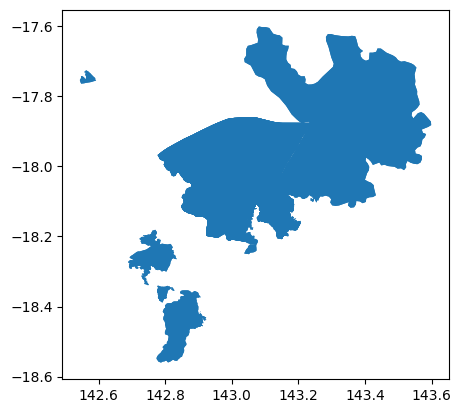

In [8]:
poly.plot()

In [24]:
# input_file = '/home/jovyan/gdata1/projects/Hazards/burn_severity/fire_extents_2025-26_summer/all_fires_at_29JAN26.gpkg'
# #define input file

# poly = gpd.read_file(input_file)
# #open as a geopandas geodataframe and have a look at the first few rows

# #let's peek at the first one
# poly.iloc[0]

## check attributes

code asumes your input polygons have the attributes defined by the trigger product data dictionary. Shapefiles do this fun thing where they shorten long attribute names, so if you are using a shapefile we will fix that up now. 
        'fire_id',
        'fire_name',
        'fire_type',
        'ignition_date',
        'capt_date',
        'capt_method',
        'area_ha',
        'perim_km',
        'state',
        'agency'
        'date_retrieved'
        'date_processed'

if your polygon dosn't have the correct attibutes (they can be empty they just need to be there) the script will get Angry at you and not run

        

In [25]:
#test attribute format

poly = test_polygon_attributes(all_boundaries_in_database)

In [26]:
poly

,fire_id,fire_name,fire_type,ignition_date,capt_date,capt_method,area_ha,perim_km,state,agency,date_retrieved,date_processed,geometry
0,102636004,Tallandoon - Yabba Road,Current Burnt Area,2025-11-01,2025-11-03,Satellite Imagery Sentinel,7.8400000000,2.3300000000,VIC,"Vic Department of Energy, Environment and Clim...",2025-11-04,2025-11-11,"MULTIPOLYGON (((147.25051 -36.42283, 147.25047..."
1,629044,"CRESCENT HEAD RD, CRESCENT HEAD",Bushfire,NaT,2025-11-04,None,2.6900000000,0.7900000000,NSW,Rural Fire Service,2025-11-04,2025-11-11,"MULTIPOLYGON (((152.93944 -31.16917, 152.93941..."
2,2b163b9b-2997-4a2e-bb90-30638dbe3ab3,None,None,2025-11-03,2025-11-03,FIREMAPPER,20370.9100000000,137.5000000000,QLD,Qld Fire and Emergency Services,2025-11-04,2025-11-11,"POLYGON ((150.55255 -27.88581, 150.55268 -27.8..."
3,e6e34de9-6158-4ee7-9024-eae94b80c422,None,None,2025-10-29,2025-11-02,FIREMAPPER,1442.6000000000,20.3600000000,QLD,Qld Fire and Emergency Services,2025-11-03,2025-11-11,"POLYGON ((142.79364 -18.38440, 142.79364 -18.3..."
4,243646,Unnamed Fire - 243646,Current Burnt Area,2025-11-02,2025-11-02,Field Intelligence Field Intelligence and Fire...,58.3600000000,3.7500000000,VIC,Vic Country Fire Authority,2025-11-03,2025-11-11,"MULTIPOLYGON (((143.53699 -35.62578, 143.53677..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3869,640253,"BRASSKNOCKER FIRETRAIL, YOWRIE",Bushfire,NaT,2026-01-27,None,4155.2100000000,65.2900000000,NSW,NSW National Parks and Wildlife Service,2026-01-27,2026-02-04,"MULTIPOLYGON (((149.73710 -36.19692, 149.73867..."
3870,102612019,Carlisle River - Pipeline Road,Current Burnt Area,2026-01-27,2026-01-27,Linescan,11326.7900000000,104.7100000000,VIC,"Vic Department of Energy, Environment and Clim...",2026-01-27,2026-02-04,"MULTIPOLYGON (((143.44526 -38.44488, 143.44505..."
3871,102622058,Colignan - Brown Road,Current Burnt Area,NaT,2026-01-27,Satellite Imagery,8.3900000000,2.2600000000,VIC,"Vic Department of Energy, Environment and Clim...",2026-01-27,2026-02-04,"MULTIPOLYGON (((142.37947 -34.56635, 142.37907..."
3872,643880,"PACIFIC HWY, NERONG",Bushfire,NaT,2026-01-27,None,38.3000000000,3.0700000000,NSW,Rural Fire Service,2026-01-27,2026-02-04,"MULTIPOLYGON (((152.22006 -32.53465, 152.22140..."


## pre-filtering

pre-filtering steps on polygons:
- remove any polygons with no area or smaller than 1 ha
- check for duplicates for the same fire and perfrom spatial join on them


In [ ]:
# TODO Cate - you can set the minimum area in the config object
mature_fires = database.perform_pre_filter(all_boundaries_in_database)

# #filter on size 
# poly = poly.drop(poly[poly.area_ha < 1].index)

# #list all fire 'id' names
# list_of_fires = list(set(poly['fire_id']))

# #perform spatial dissolve on overlapping polygons with same id
# dissolved_duplicates = perform_spatial_dissolve(poly, list_of_fires)

In [28]:
mature_fires.iloc[0]

geometry          POLYGON ((147.096306 -41.514642, 147.096225 -4...
fire_id                                                    26003609
fire_name                                     Pateena road Longford
fire_type                                           VEGETATION FIRE
capt_method                                                    None
area_ha                                                2.1700000000
perim_km                                               0.5900000000
state                                                           TAS
agency                                             Tas Fire Service
date_retrieved                                  2026-01-24 00:00:00
ignition_date                                                   NaN
capt_date                                       2026-01-23 00:00:00
date_processed                                           2026-01-31
Name: 0, dtype: object

## Filter by age

we only want to run our process of files older that 60 days. that is filres that have been extinguished for more than 60 days


In [ ]:
# TODO Cate - this is handled in the filter step, you can set the parameters in the config object at the top
# today_date = date.today()

# cutoff_date = today_date - timedelta(days=65)

# mature_fires = dissolved_duplicates[dissolved_duplicates.date_processed <= cutoff_date]

# #make all nan 0 to eliminate cate's date filtering headache!!
# mature_fires = mature_fires.fillna(0)

/tmp/ipykernel_137/1139670586.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mature_fires = mature_fires.fillna(0)


In [30]:
processed_dates = list(set(mature_fires['date_processed']))

In [31]:
processed_dates

[datetime.date(2025, 11, 24),
 datetime.date(2025, 11, 18),
 datetime.date(2025, 11, 26),
 datetime.date(2025, 12, 1),
 datetime.date(2025, 12, 2),
 datetime.date(2025, 11, 27),
 datetime.date(2025, 11, 17),
 datetime.date(2025, 11, 16),
 datetime.date(2025, 11, 30),
 datetime.date(2025, 11, 19),
 datetime.date(2025, 11, 11),
 datetime.date(2025, 11, 12),
 datetime.date(2025, 11, 14),
 datetime.date(2025, 11, 28),
 datetime.date(2025, 11, 22),
 datetime.date(2025, 11, 15),
 datetime.date(2025, 11, 20),
 datetime.date(2025, 11, 13),
 datetime.date(2025, 11, 25),
 datetime.date(2025, 11, 21),
 datetime.date(2025, 11, 29),
 datetime.date(2025, 11, 23)]

# For NOTEBOOK USE ONLY

the next four cells further filter mature fires to process only one day at a time in order to more easily manage workload when conducting manual backfill.
this dosn't need to be copied to the pipline 

In [80]:
date_to_use = date(2025, 11, 17)
process_today = mature_fires[mature_fires['date_processed'] == date_to_use]

In [81]:
len(process_today)

12

In [82]:
analysis_out_folder= f'{output_folder}/{str(date_to_use)}'
os.makedirs(analysis_out_folder, exist_ok=True)

In [83]:
log_file = 'results/processed_fires.txt'

## map burn severity


In [ ]:

#this essentially creates a numerical list of each dissolved fire
for fires in range(0,len(process_today.index)):

    
    #select each polygon one-by -one
    fire_polygon = gpd.GeoDataFrame(process_today.iloc[fires].to_frame().T, geometry='geometry', crs=process_today.crs)

    #make a sting which is fire id and position in gpd to not over-write re-use of ids in QLD
    fire_id_forsave = f'{fire_polygon.fire_id.iloc[0]}_{fires}'
    
    #run burn severity mapping
    Severity_polygons, debug_layer = map_burn_severity(fire_polygon)

       # #save_debug layer to file
    write_cog(debug_layer.compute(), f'{analysis_out_folder}/DEA_burn_severity_debug_{fire_id_forsave}.tif',
             overwrite=True)

    Severity_polygons.to_file(f'{analysis_out_folder}/DEA_burn_severity_{fire_id_forsave}.{file_format}')

    #add index to file
    
    text_to_add = f"({fire_polygon.fire_id.iloc[0]}, {fire_polygon.date_processed.iloc[0]}),\n"
    
    with open(log_file, "a") as file:
        file.write(text_to_add)

    
    print( f'I finished processing number {fires}')
    


CONDUCTING BURN SEVERITY MAPPING                                              geometry  \
99  POLYGON ((147.18517 -24.99234, 147.18491 -24.9...   

                                 fire_id fire_name fire_type capt_method  \
99  a9f74cb7-b7a2-484d-9cba-8b6fb0775c26         0         0  FIREMAPPER   

            area_ha       perim_km state                           agency  \
99  7447.5300000000  45.7400000000   QLD  Qld Fire and Emergency Services   

         date_retrieved        ignition_date            capt_date  \
99  2025-11-07 00:00:00  2025-11-06 00:00:00  2025-11-07 00:00:00   

   date_processed  
99     2025-11-17  
date as string is 2025-11-06 00:00:00
date as string is 2025-11-17
Finding datasets
    ga_s2am_ard_3
    ga_s2bm_ard_3
    ga_s2cm_ard_3
Counting good quality pixels for each time step using s2cloudless
Filtering to 2 out of 5 time steps with at least 99.0% good quality pixels
Applying s2cloudless pixel quality/cloud mask
Returning 2 time steps as a dask array
D